In [ ]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Konfigurasi gaya tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

print("✅ Library berhasil dimuat!")

✅ Library berhasil dimuat!


In [ ]:
# Jika menggunakan file CSV sendiri:
# df = pd.read_csv('speedtest_data.csv')

# --- JIKA BELUM MEMILIKI FILE, SCRIPT INI AKAN MEMBUAT SIMULASI DATASET (5.084 Observasi) ---
np.random.seed(42)

# Simulasi data Fixed (Wi-Fi) - 2.597 data
n_fixed = 2597
fixed_download = np.random.lognormal(mean=3.4, sigma=0.8, size=n_fixed)
fixed_download = np.clip(fixed_download, 0.61, 237.38)
fixed_upload = fixed_download * np.random.uniform(0.3, 0.8, size=n_fixed)
fixed_latency = np.random.lognormal(mean=3.2, sigma=0.5, size=n_fixed) + 3

# Simulasi data Mobile (Seluler) - 2.487 data
n_mobile = 2487
mobile_download = np.random.lognormal(mean=3.3, sigma=0.6, size=n_mobile)
mobile_download = np.clip(mobile_download, 0.02, 252.90)
mobile_upload = mobile_download * np.random.uniform(0.2, 0.6, size=n_mobile)
mobile_latency = np.random.lognormal(mean=4.0, sigma=0.6, size=n_mobile) + 15

df_fixed = pd.DataFrame({
    'connection_type': 'Fixed',
    'download_speed': fixed_download,
    'upload_speed': fixed_upload,
    'latency': fixed_latency
})

df_mobile = pd.DataFrame({
    'connection_type': 'Mobile',
    'download_speed': mobile_download,
    'upload_speed': mobile_upload,
    'latency': mobile_latency
})

df = pd.concat([df_fixed, df_mobile], ignore_index=True)

print("✅ Dataset berhasil dimuat!")
print(f"Total Baris Data: {len(df)}")
df.head()

✅ Dataset berhasil dimuat!
Total Baris Data: 5084


,connection_type,download_speed,upload_speed,latency
0,Fixed,44.583834,21.745072,30.266037
1,Fixed,26.826456,18.829684,31.246213
2,Fixed,50.307332,25.995615,25.502616
3,Fixed,101.334192,80.924592,32.475161
4,Fixed,24.845516,14.398713,25.947319


In [ ]:
# Fungsi untuk menghitung ringkasan statistik
def get_stats(data, col_name):
    return {
        'Mean': data[col_name].mean(),
        'Median': data[col_name].median(),
        'Std Dev': data[col_name].std(),
        'Min': data[col_name].min(),
        'Max': data[col_name].max(),
        'Skewness': data[col_name].skew()
    }

# Ringkasan per variabel
stats_overall = pd.DataFrame([get_stats(df, 'download_speed')], index=['Download Overall'])
stats_fixed = pd.DataFrame([get_stats(df[df['connection_type']=='Fixed'], 'download_speed')], index=['Fixed Download'])
stats_mobile = pd.DataFrame([get_stats(df[df['connection_type']=='Mobile'], 'download_speed')], index=['Mobile Download'])
stats_upload = pd.DataFrame([get_stats(df, 'upload_speed')], index=['Upload Speed'])
stats_latency = pd.DataFrame([get_stats(df, 'latency')], index=['Latency (Ping)'])

tabel_deskriptif = pd.concat([stats_overall, stats_fixed, stats_mobile, stats_upload, stats_latency])
print("=== TABEL 4.1: STATISTIKA DESKRIPTIF INDIKATOR UTAMA JARINGAN ===")
display(tabel_deskriptif.round(2))

=== TABEL 4.1: STATISTIKA DESKRIPTIF INDIKATOR UTAMA JARINGAN ===


,Mean,Median,Std Dev,Min,Max,Skewness
Download Overall,37.27,28.66,30.80,2.24,237.38,2.70
Fixed Download,41.77,30.60,36.95,2.24,237.38,2.38
Mobile Download,32.56,26.95,21.67,3.94,227.34,2.28
Upload Speed,18.04,12.73,17.43,1.02,184.86,3.12
Latency (Ping),55.39,43.55,41.80,7.09,442.24,2.35


/tmp/ipykernel_1900/644637430.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='connection_type', y='download_speed',


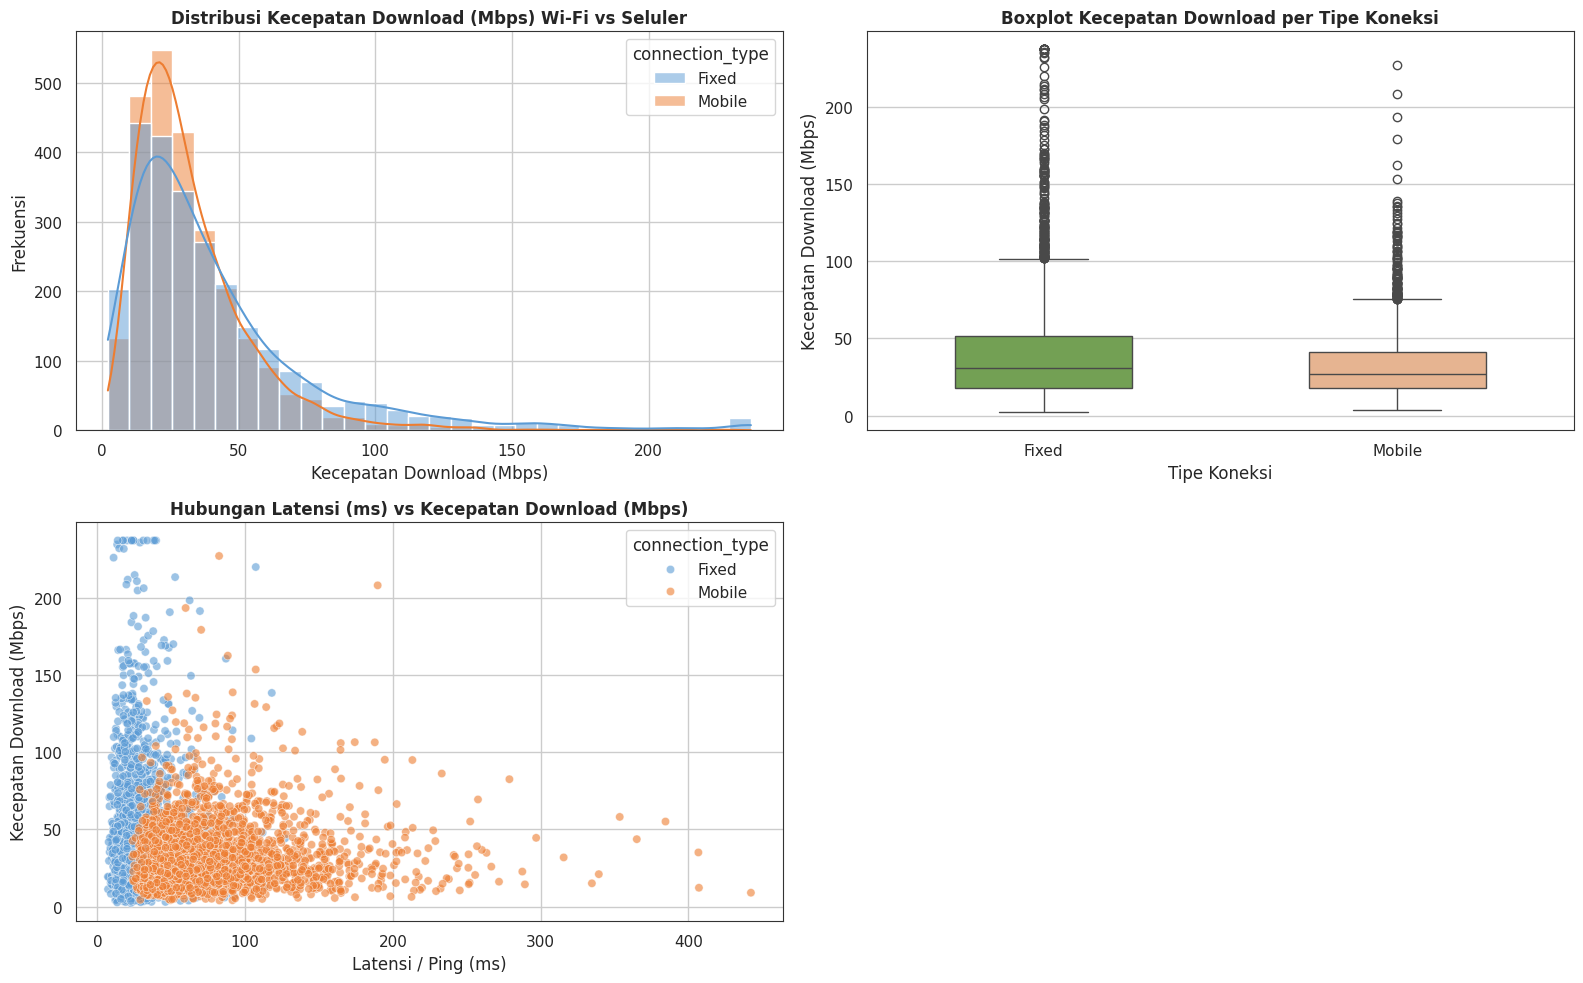

✅ Gambar visualisasi berhasil disimpan sebagai 'visualisasi_kecepatan_internet.png'


In [ ]:
fig = plt.figure(figsize=(16, 10))

# 1. Histogram & KDE Distribusi Kecepatan Download
ax1 = fig.add_subplot(2, 2, 1)
sns.histplot(data=df, x='download_speed', hue='connection_type', kde=True,
             palette={'Fixed': '#5b9bd5', 'Mobile': '#ed7d31'}, bins=30, ax=ax1)
ax1.set_title('Distribusi Kecepatan Download (Mbps) Wi-Fi vs Seluler', fontsize=12, fontweight='bold')
ax1.set_xlabel('Kecepatan Download (Mbps)')
ax1.set_ylabel('Frekuensi')

# 2. Boxplot Kecepatan Download per Tipe Koneksi
ax2 = fig.add_subplot(2, 2, 2)
sns.boxplot(data=df, x='connection_type', y='download_speed',
            palette={'Fixed': '#70ad47', 'Mobile': '#f4b183'}, width=0.5, ax=ax2)
ax2.set_title('Boxplot Kecepatan Download per Tipe Koneksi', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tipe Koneksi')
ax2.set_ylabel('Kecepatan Download (Mbps)')

# 3. Scatter Plot Latensi vs Kecepatan Download
ax3 = fig.add_subplot(2, 2, 3)
sns.scatterplot(data=df, x='latency', y='download_speed', hue='connection_type',
                alpha=0.6, palette={'Fixed': '#5b9bd5', 'Mobile': '#ed7d31'}, ax=ax3)
ax3.set_title('Hubungan Latensi (ms) vs Kecepatan Download (Mbps)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Latensi / Ping (ms)')
ax3.set_ylabel('Kecepatan Download (Mbps)')

plt.tight_layout()
plt.savefig('visualisasi_kecepatan_internet.png', dpi=300)
plt.show()

print("✅ Gambar visualisasi berhasil disimpan sebagai 'visualisasi_kecepatan_internet.png'")

In [ ]:
fixed_dl = df[df['connection_type']=='Fixed']['download_speed']
mobile_dl = df[df['connection_type']=='Mobile']['download_speed']

# 1. Uji Levene (Homogenitas Varians)
levene_stat, levene_p = stats.levene(fixed_dl, mobile_dl)

# 2. Welch's t-test (Uji Parametrik)
welch_stat, welch_p = stats.ttest_ind(fixed_dl, mobile_dl, equal_var=False)

# 3. Mann-Whitney U test (Uji Non-Parametrik)
mw_stat, mw_p = stats.mannwhitneyu(fixed_dl, mobile_dl)

tabel_uji_beda = pd.DataFrame({
    'Uji Statistik': ["Levene's Test (Homogenitas Varians)", "Welch's Independent t-test", "Mann-Whitney U Test"],
    'Nilai Statistik': [levene_stat, welch_stat, mw_stat],
    'p-value': [levene_p, welch_p, mw_p],
    'Keputusan': ['Tolak H0' if p < 0.05 else 'Gagal Tolak H0' for p in [levene_p, welch_p, mw_p]]
})

print("=== TABEL 4.2: HASIL UJI BEDA RATA-RATA KECEPATAN DOWNLOAD ===")
display(tabel_uji_beda)

=== TABEL 4.2: HASIL UJI BEDA RATA-RATA KECEPATAN DOWNLOAD ===


,Uji Statistik,Nilai Statistik,p-value,Keputusan
0,Levene's Test (Homogenitas Varians),1.644745e+02,4.454262e-37,Tolak H0
1,Welch's Independent t-test,1.088943e+01,2.969551e-27,Tolak H0
2,Mann-Whitney U Test,3.548709e+06,1.033670e-09,Tolak H0
